In [1]:
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, BatchNormalization, ReLU, Dropout, Flatten, Dense, InputLayer
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from keras import regularizers
import tensorflow as tf
from PIL import Image
import numpy as np
import random
import shutil
import cv2
import PIL
import os

2024-05-25 21:44:36.606030: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-25 21:44:36.606161: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-25 21:44:36.859990: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
for folder in os.listdir("/kaggle/input/newdata/finalData"):
    if folder.startswith('V'):
        print(" => "+ folder +" dataset contains " + str(len(os.listdir("/kaggle/input/newdata/finalData/" + folder )) // 2) + " types of vegetables.")
    else:
        print(" => "+ folder +" dataset contains " + str(len(os.listdir("/kaggle/input/newdata/finalData/" + folder )) // 2) + " types of fruits.")
print(" => " + "Total fruitsVegetables dataset contains " + str(6) + " types.") 

 => Vegetables dataset contains 3 types of vegetables.
 => Fruits dataset contains 4 types of fruits.
 => Total fruitsVegetables dataset contains 6 types.


In [3]:
totalFresh = 0
totalRotten = 0
all_ = 0

for folder in os.listdir("/kaggle/input/newdata/finalData/Fruits/"):
    if folder.startswith('F'):
        Fsize = len(os.listdir("/kaggle/input/newdata/finalData/Fruits/" + folder))
        print(" => "+ folder +" Fruits folder contains " + str(Fsize) + " fresh fruits images.")
        totalFresh += Fsize
    else:
        Vsize = len(os.listdir("/kaggle/input/newdata/finalData/Fruits/" + folder))
        print(" => "+ folder +" Fruits folder contains " + str(Vsize) + " rotten fruits images.")
        totalRotten += Vsize
        
print("----------------------------------------------------------------------")
print("Fresh fruits dataset contains " + str(totalFresh) + " images")
print("Rotten fruits dataset contains " + str(totalRotten) + " images")
print("Fruits Dataset contains " + str(totalFresh+totalRotten) + " images")

 => RottenBanana Fruits folder contains 8000 rotten fruits images.
 => FreshOranges Fruits folder contains 8081 fresh fruits images.
 => RottenOranges Fruits folder contains 8000 rotten fruits images.
 => RottenGrape Fruits folder contains 6622 rotten fruits images.
 => FreshBanana Fruits folder contains 8119 fresh fruits images.
 => RottenApples Fruits folder contains 8000 rotten fruits images.
 => FreshApples Fruits folder contains 8145 fresh fruits images.
 => FreshGrape Fruits folder contains 7000 fresh fruits images.
----------------------------------------------------------------------
Fresh fruits dataset contains 31345 images
Rotten fruits dataset contains 30622 images
Fruits Dataset contains 61967 images


In [4]:
totalFresh = 0
totalRotten = 0
all_ = 0

for folder in os.listdir("/kaggle/input/newdata/finalData/Vegetables/"):
    if folder.startswith('F'):
        Fsize = len(os.listdir("/kaggle/input/newdata/finalData/Vegetables/" + folder))
        print(" => "+ folder +" Vegetables folder contains " + str(Fsize) + " fresh vegetables images.")
        totalFresh += Fsize
    else:
        Vsize = len(os.listdir("/kaggle/input/newdata/finalData/Vegetables/" + folder))
        print(" => "+ folder +" Vegetables folder contains " + str(Vsize) + " rotten vegetables images.")
        totalRotten += Vsize
        
print("------------------------------------------------------------------------------")
print("Fresh vegetables dataset contains " + str(totalFresh) + " images")
print("Rotten vegetables dataset contains " + str(totalRotten) + " images")
print("Vegetables Dataset contains " + str(totalFresh+totalRotten) + " images")

 => RottenBellpepper Vegetables folder contains 1116 rotten vegetables images.
 => FreshBellpepper Vegetables folder contains 8000 fresh vegetables images.
 => FreshBittergourd Vegetables folder contains 8000 fresh vegetables images.
 => FreshCucumber Vegetables folder contains 6895 fresh vegetables images.
 => RottenCucumber Vegetables folder contains 1848 rotten vegetables images.
 => RottenBittergourd Vegetables folder contains 8000 rotten vegetables images.
------------------------------------------------------------------------------
Fresh vegetables dataset contains 22895 images
Rotten vegetables dataset contains 10964 images
Vegetables Dataset contains 33859 images


In [5]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Define the root directory where your dataset is stored
root_dir = '/kaggle/input/newdata/finalData/'

# Define the classes (folders) in your dataset
classes = {
    'Fruits': ['FreshApples', 'FreshBanana', 'FreshGrape', 'FreshOranges', 'RottenApples', 'RottenBanana', 'RottenGrape', 'RottenOranges'],
    'Vegetables': ['FreshBellpepper', 'FreshBittergourd', 'FreshCucumber', 'RottenBellpepper', 'RottenBittergourd', 'RottenCucumber']
}

# Initialize lists to store data
X_train, X_val, X_test = [], [], []
y_train, y_val, y_test = [], [], []

# Function to load images
def load_images_from_folder(filename):
    images = []
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150, 150))  
    images.append(img)
    return images

# Iterate over each folder (Fruits and Vegetables)
for folder, subfolders in classes.items():
    for subfolder in subfolders:
        # Define the path to the subfolder directory
        subfolder_dir = os.path.join(root_dir, folder, subfolder)
        # List all the files in the subfolder directory
        files = os.listdir(subfolder_dir)
        # Split the files into train, validation, and test sets
        train_files, test_val_files = train_test_split(files, test_size=0.2, random_state=42)
        val_files, test_files = train_test_split(test_val_files, test_size=0.5, random_state=42)

        # Add the images to respective lists
        X_train.extend(load_images_from_folder(os.path.join(subfolder_dir, file)) for file in train_files)
        X_val.extend(load_images_from_folder(os.path.join(subfolder_dir, file)) for file in val_files)
        X_test.extend(load_images_from_folder(os.path.join(subfolder_dir, file)) for file in test_files)

        # Add labels to respective lists
        y_train.extend([subfolder] * len(train_files))
        y_val.extend([subfolder] * len(val_files))
        y_test.extend([subfolder] * len(test_files))

# Convert lists to numpy arrays
X_train, X_val, X_test = np.array(X_train), np.array(X_val), np.array(X_test)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(y_test)

# Optionally, you can shuffle the data
shuffle_indices_train = np.random.permutation(len(X_train))
shuffle_indices_val = np.random.permutation(len(X_val))
shuffle_indices_test = np.random.permutation(len(X_test))

# Ensure that shuffle indices are within bounds
shuffle_indices_train = shuffle_indices_train[:len(X_train)]
shuffle_indices_val = shuffle_indices_val[:len(X_val)]
shuffle_indices_test = shuffle_indices_test[:len(X_test)]

X_train, y_train = X_train[shuffle_indices_train], y_train[shuffle_indices_train]
X_val, y_val = X_val[shuffle_indices_val], y_val[shuffle_indices_val]
X_test, y_test = X_test[shuffle_indices_test], y_test[shuffle_indices_test]

# Reshape arrays to remove the unnecessary dimension
X_train = np.squeeze(X_train, axis=1)
X_val = np.squeeze(X_val, axis=1)
X_test = np.squeeze(X_test, axis=1)

In [6]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("y_val shape:", y_val.shape)

X_train shape: (76658, 150, 150, 3)
X_test shape: (9586, 150, 150, 3)
X_val shape: (9582, 150, 150, 3)
y_train shape: (76658,)
y_test shape: (9586,)
y_val shape: (9582,)


In [7]:
le = LabelEncoder()

In [8]:
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_val = le.transform(y_val)

In [9]:
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(mapping)

{'FreshApples': 0, 'FreshBanana': 1, 'FreshBellpepper': 2, 'FreshBittergourd': 3, 'FreshCucumber': 4, 'FreshGrape': 5, 'FreshOranges': 6, 'RottenApples': 7, 'RottenBanana': 8, 'RottenBellpepper': 9, 'RottenBittergourd': 10, 'RottenCucumber': 11, 'RottenGrape': 12, 'RottenOranges': 13}


In [10]:
X_train = tf.convert_to_tensor(X_train)
y_train = tf.convert_to_tensor(y_train)

In [11]:
X_test = tf.convert_to_tensor(X_test)
y_test = tf.convert_to_tensor(y_test)

In [12]:
X_val = tf.convert_to_tensor(X_val)
y_val = tf.convert_to_tensor(y_val)

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPool2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

model = Sequential([
    InputLayer(input_shape=(150, 150, 3)),
    
    Conv2D(filters=32, kernel_size=3, padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    MaxPool2D(pool_size=(2, 2), padding="same"),
    BatchNormalization(),
    
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), padding="same"),
    BatchNormalization(),
    
    Conv2D(filters=128, kernel_size=3, padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    MaxPool2D(pool_size=(2, 2), padding="same"),
    BatchNormalization(),
    
    Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"),
    MaxPool2D(pool_size=(2, 2), padding="same"),
    BatchNormalization(),
    
    Conv2D(filters=512, kernel_size=3, padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    MaxPool2D(pool_size=(2, 2), padding="same"),
    BatchNormalization(),
    
    Flatten(),
    Dense(1024, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(14, activation='softmax')
])

In [14]:
num_epochs = 350

In [15]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
# model.summary()

In [17]:
history = model.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = num_epochs, batch_size = 64)

Epoch 1/350


I0000 00:00:1716675194.199612      73 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1198/1198 [==============================] - 91s 65ms/step - loss: 2.8879 - accuracy: 0.7691 - val_loss: 1.4762 - val_accuracy: 0.8511
Epoch 2/350
1198/1198 [==============================] - 75s 63ms/step - loss: 1.2700 - accuracy: 0.8784 - val_loss: 1.2537 - val_accuracy: 0.8591
Epoch 3/350
1198/1198 [==============================] - 76s 63ms/step - loss: 1.0612 - accuracy: 0.9098 - val_loss: 1.0723 - val_accuracy: 0.8979
Epoch 4/350
1198/1198 [==============================] - 76s 63ms/step - loss: 0.9725 - accuracy: 0.9235 - val_loss: 1.1859 - val_accuracy: 0.8558
Epoch 5/350
1198/1198 [==============================] - 76s 63ms/step - loss: 0.8309 - accuracy: 0.9382 - val_loss: 0.7926 - val_accuracy: 0.9241
Epoch 6/350
1198/1198 [==============================] - 76s 63ms/step - loss: 0.7058 - accuracy: 0.9469 - val_loss: 0.7164 - val_accuracy: 0.9325
Epoch 7/350
1198/1198 [==============================] - 76s 63ms/step - loss: 0.6221 - accuracy: 0.9546 - val_loss: 1.1000 - val_

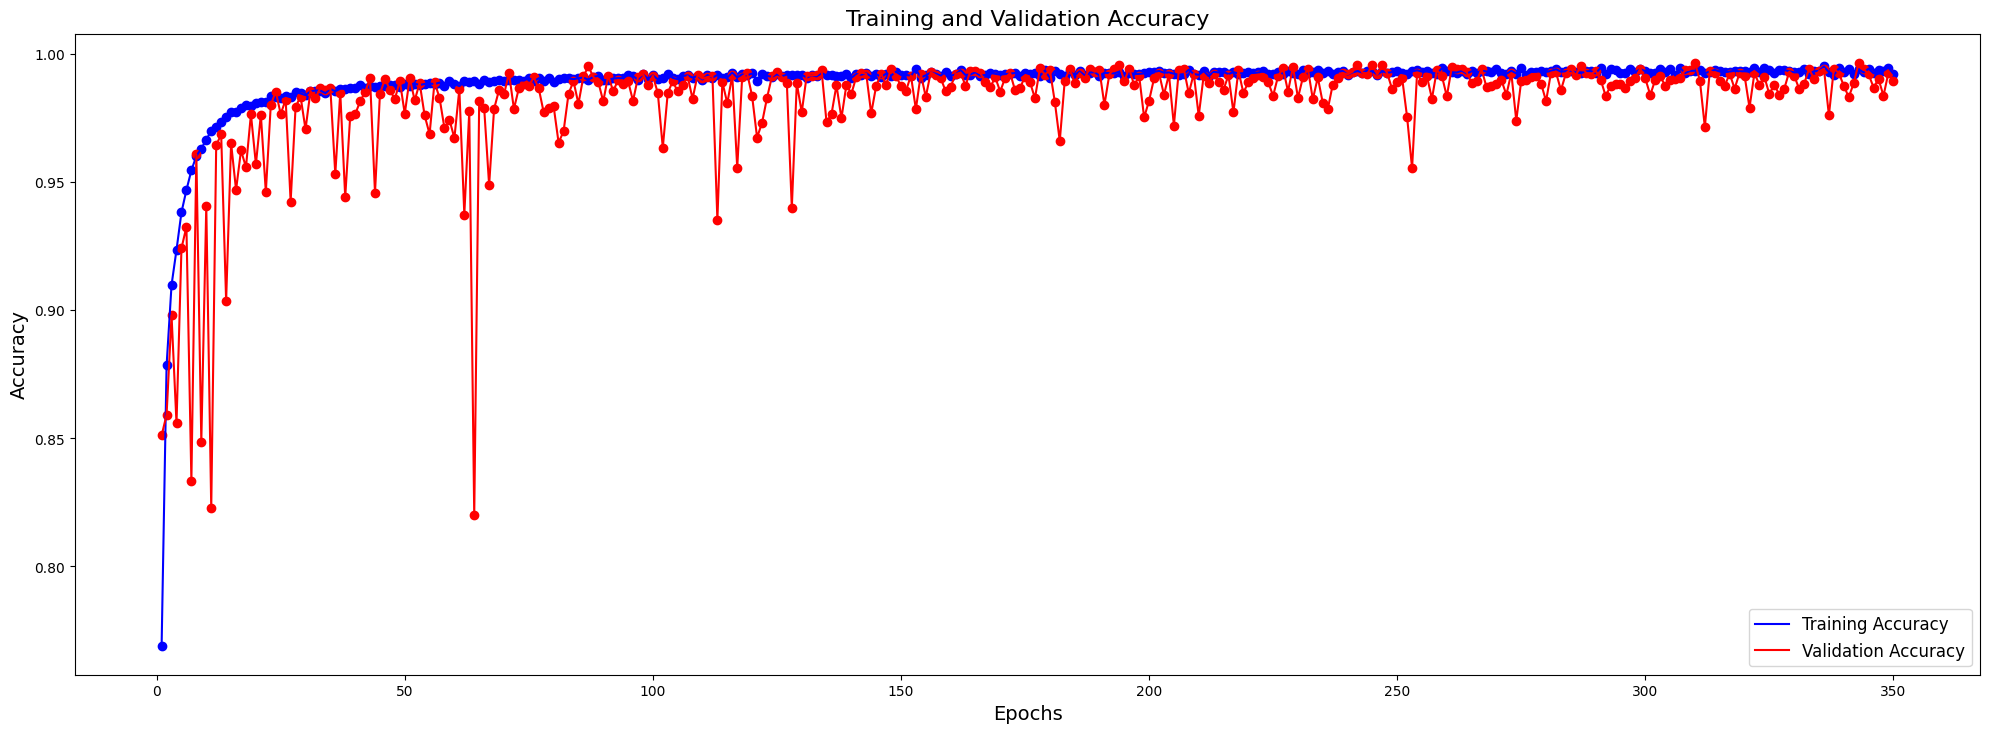

In [18]:
plt.figure(figsize=(20, 14))

# Plot Accuracy
plt.subplot(2, 1, 1)
plt.plot(range(1, num_epochs+1), history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=1.5)
plt.plot(range(1, num_epochs+1), history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=1.5)
plt.scatter(range(1, num_epochs+1), history.history['accuracy'], color='blue')
plt.scatter(range(1, num_epochs+1), history.history['val_accuracy'], color='red')
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(loc='best', fontsize=12)

plt.tight_layout()
plt.show()

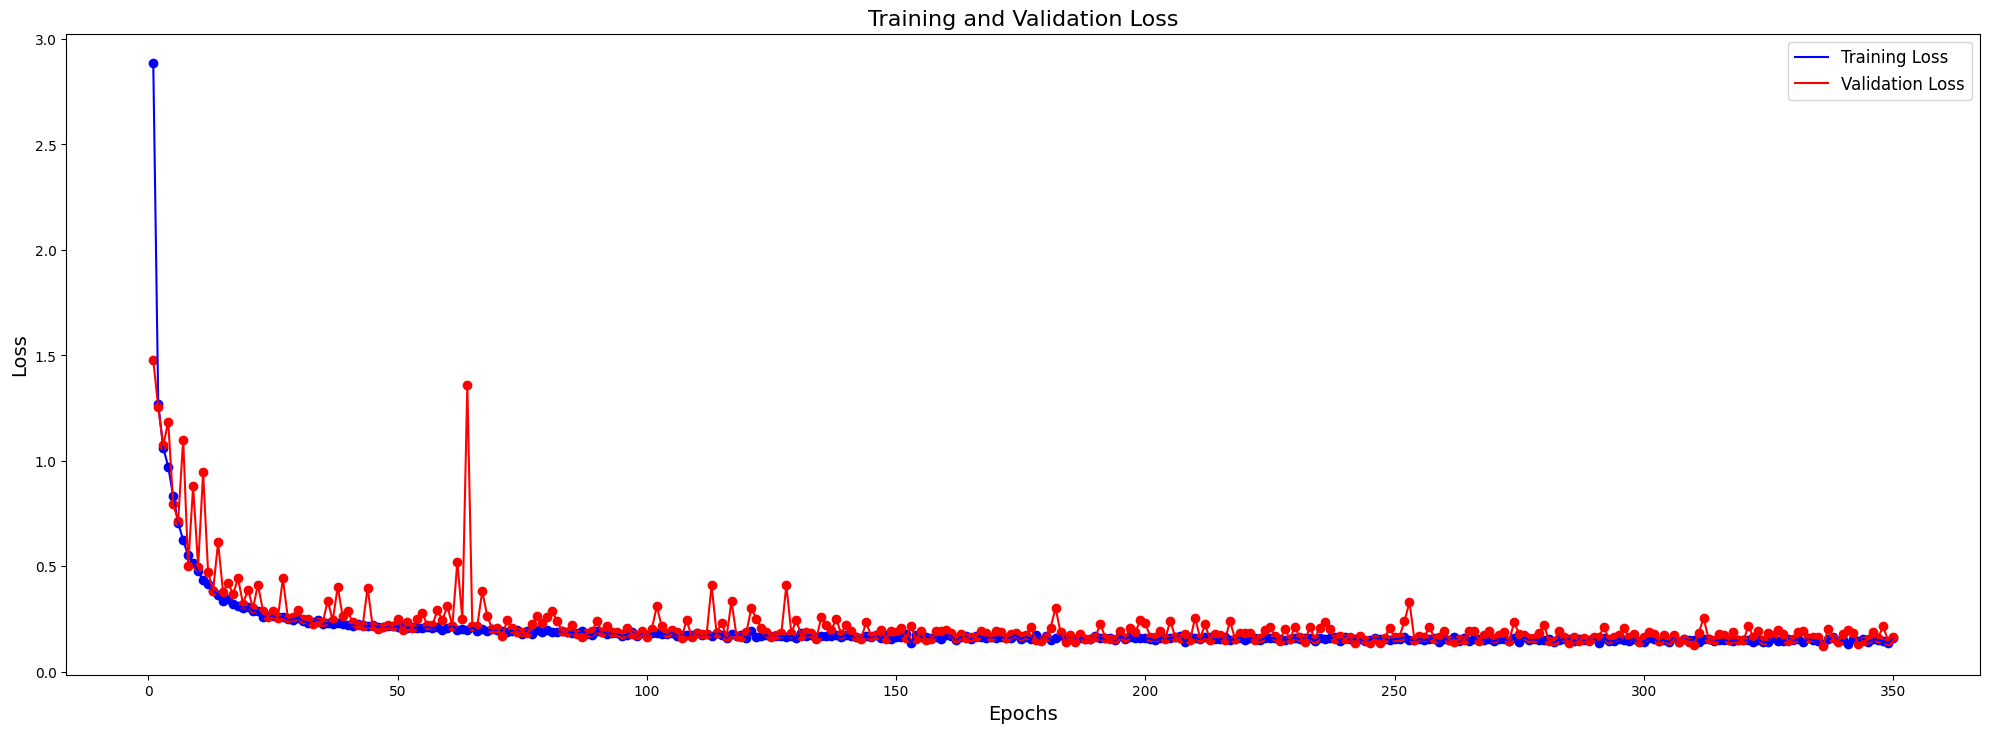

In [19]:
plt.figure(figsize=(20, 14))

# Plot Loss
plt.subplot(2, 1, 2)
plt.plot(range(1, num_epochs+1), history.history['loss'], label='Training Loss', color='blue', linewidth=1.5)
plt.plot(range(1, num_epochs+1), history.history['val_loss'], label='Validation Loss', color='red', linewidth=1.5)
plt.scatter(range(1, num_epochs+1), history.history['loss'], color='blue')
plt.scatter(range(1, num_epochs+1), history.history['val_loss'], color='red')
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(loc='best', fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
pred = model.predict(X_test)

300/300 [==============================] - 4s 10ms/step


In [21]:
pred = pred.argmax(axis = 1)

In [22]:
scores = model.evaluate(X_test, y_test)

300/300 [==============================] - 3s 10ms/step - loss: 0.1520 - accuracy: 0.9902


In [23]:
print(classification_report(y_test,pred,target_names = list(mapping.keys())))

                   precision    recall  f1-score   support

      FreshApples       0.99      1.00      0.99       815
      FreshBanana       0.99      1.00      1.00       812
  FreshBellpepper       0.99      1.00      0.99       800
 FreshBittergourd       1.00      1.00      1.00       800
    FreshCucumber       0.99      0.99      0.99       690
       FreshGrape       1.00      1.00      1.00       700
     FreshOranges       0.99      0.99      0.99       809
     RottenApples       0.96      0.98      0.97       800
     RottenBanana       0.98      1.00      0.99       800
 RottenBellpepper       0.98      0.95      0.96       112
RottenBittergourd       1.00      1.00      1.00       800
   RottenCucumber       0.98      0.97      0.98       185
      RottenGrape       1.00      1.00      1.00       663
    RottenOranges       1.00      0.95      0.97       800

         accuracy                           0.99      9586
        macro avg       0.99      0.99      0.99      

In [24]:
target_names = list(mapping.keys())

In [25]:
model.save('best.h5')

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


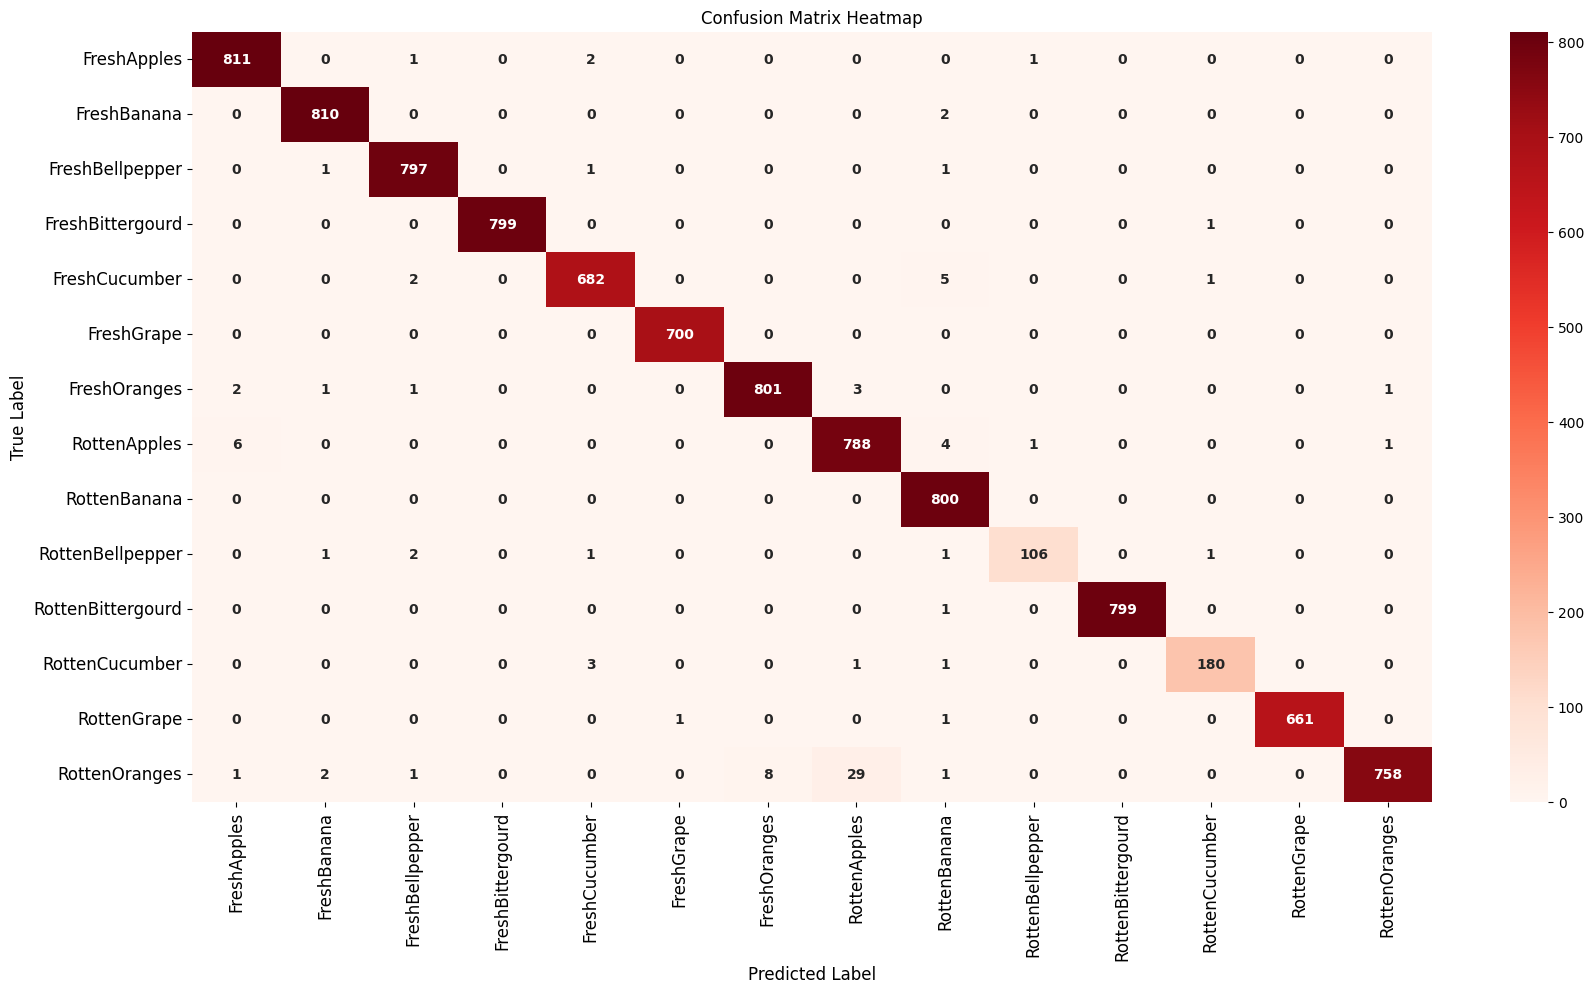

In [26]:
plt.figure(figsize=(20, 10))
conf_matrix = confusion_matrix(y_test, pred)
heatmap = sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names,
                      annot_kws={"weight": "bold"})

# Set the font size and weight for the x and y tick labels
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=12)

plt.title('Confusion Matrix Heatmap', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

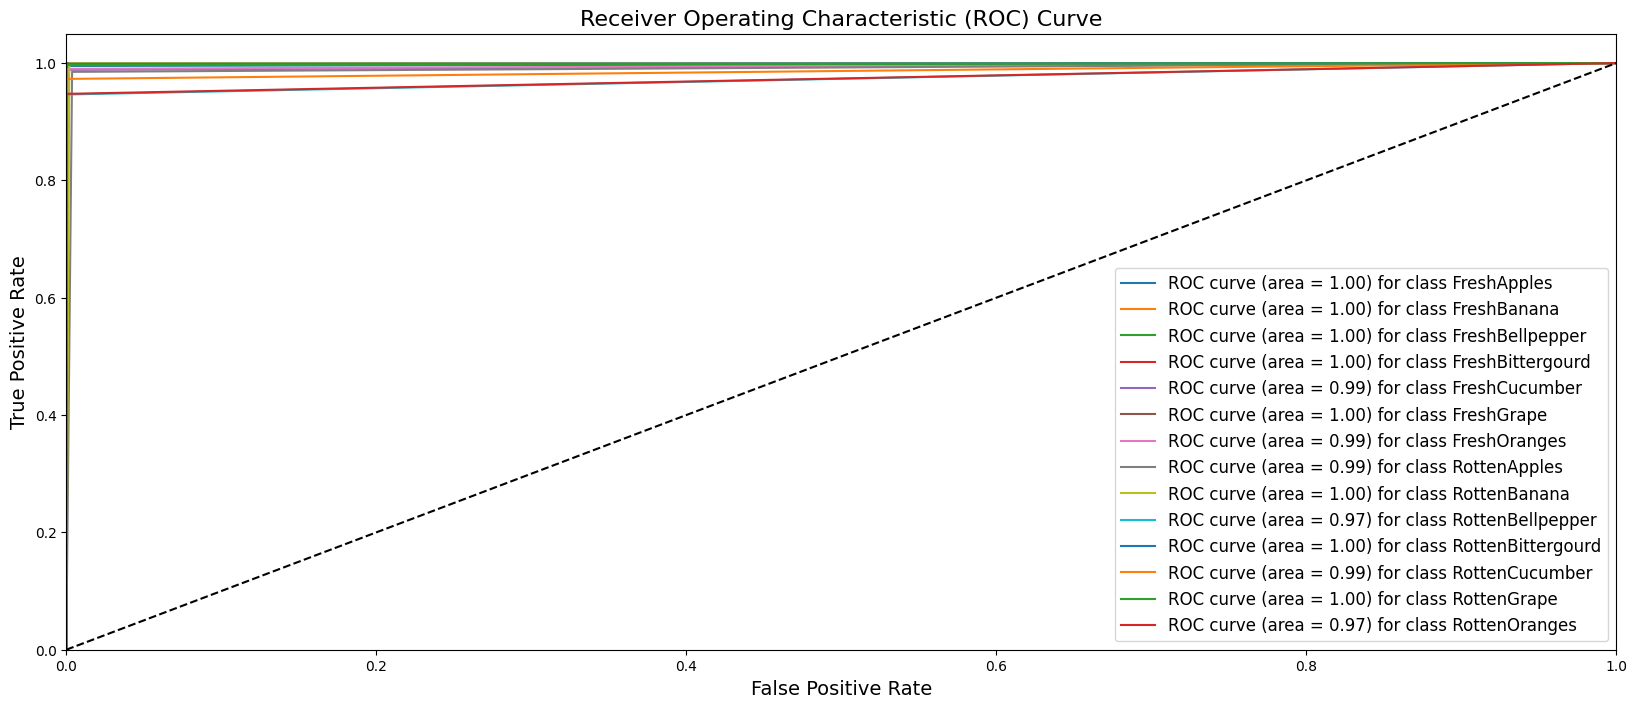

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC curve
y_test_binarized = label_binarize(y_test, classes=range(len(target_names)))
y_pred_binarized = label_binarize(pred, classes=range(len(target_names)))

plt.figure(figsize=(20, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f}) for class {target_names[i]}')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.show()

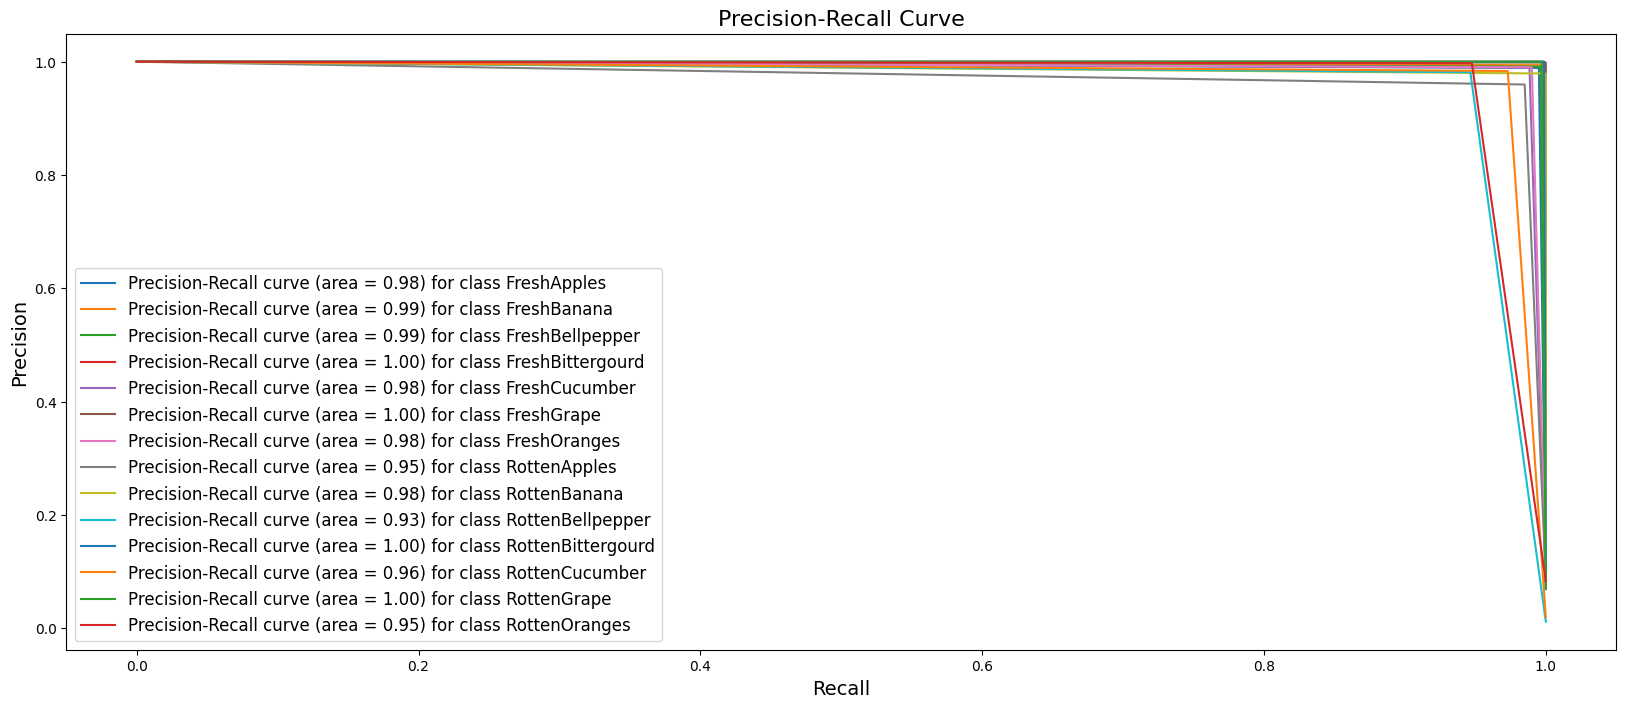

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(20, 8))
for i in range(len(target_names)):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_pred_binarized[:, i])
    average_precision = average_precision_score(y_test_binarized[:, i], y_pred_binarized[:, i])
    plt.plot(recall, precision, label=f'Precision-Recall curve (area = {average_precision:.2f}) for class {target_names[i]}')

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('Precision-Recall Curve', fontsize=16)
plt.legend(loc='lower left', fontsize=12)
plt.show()

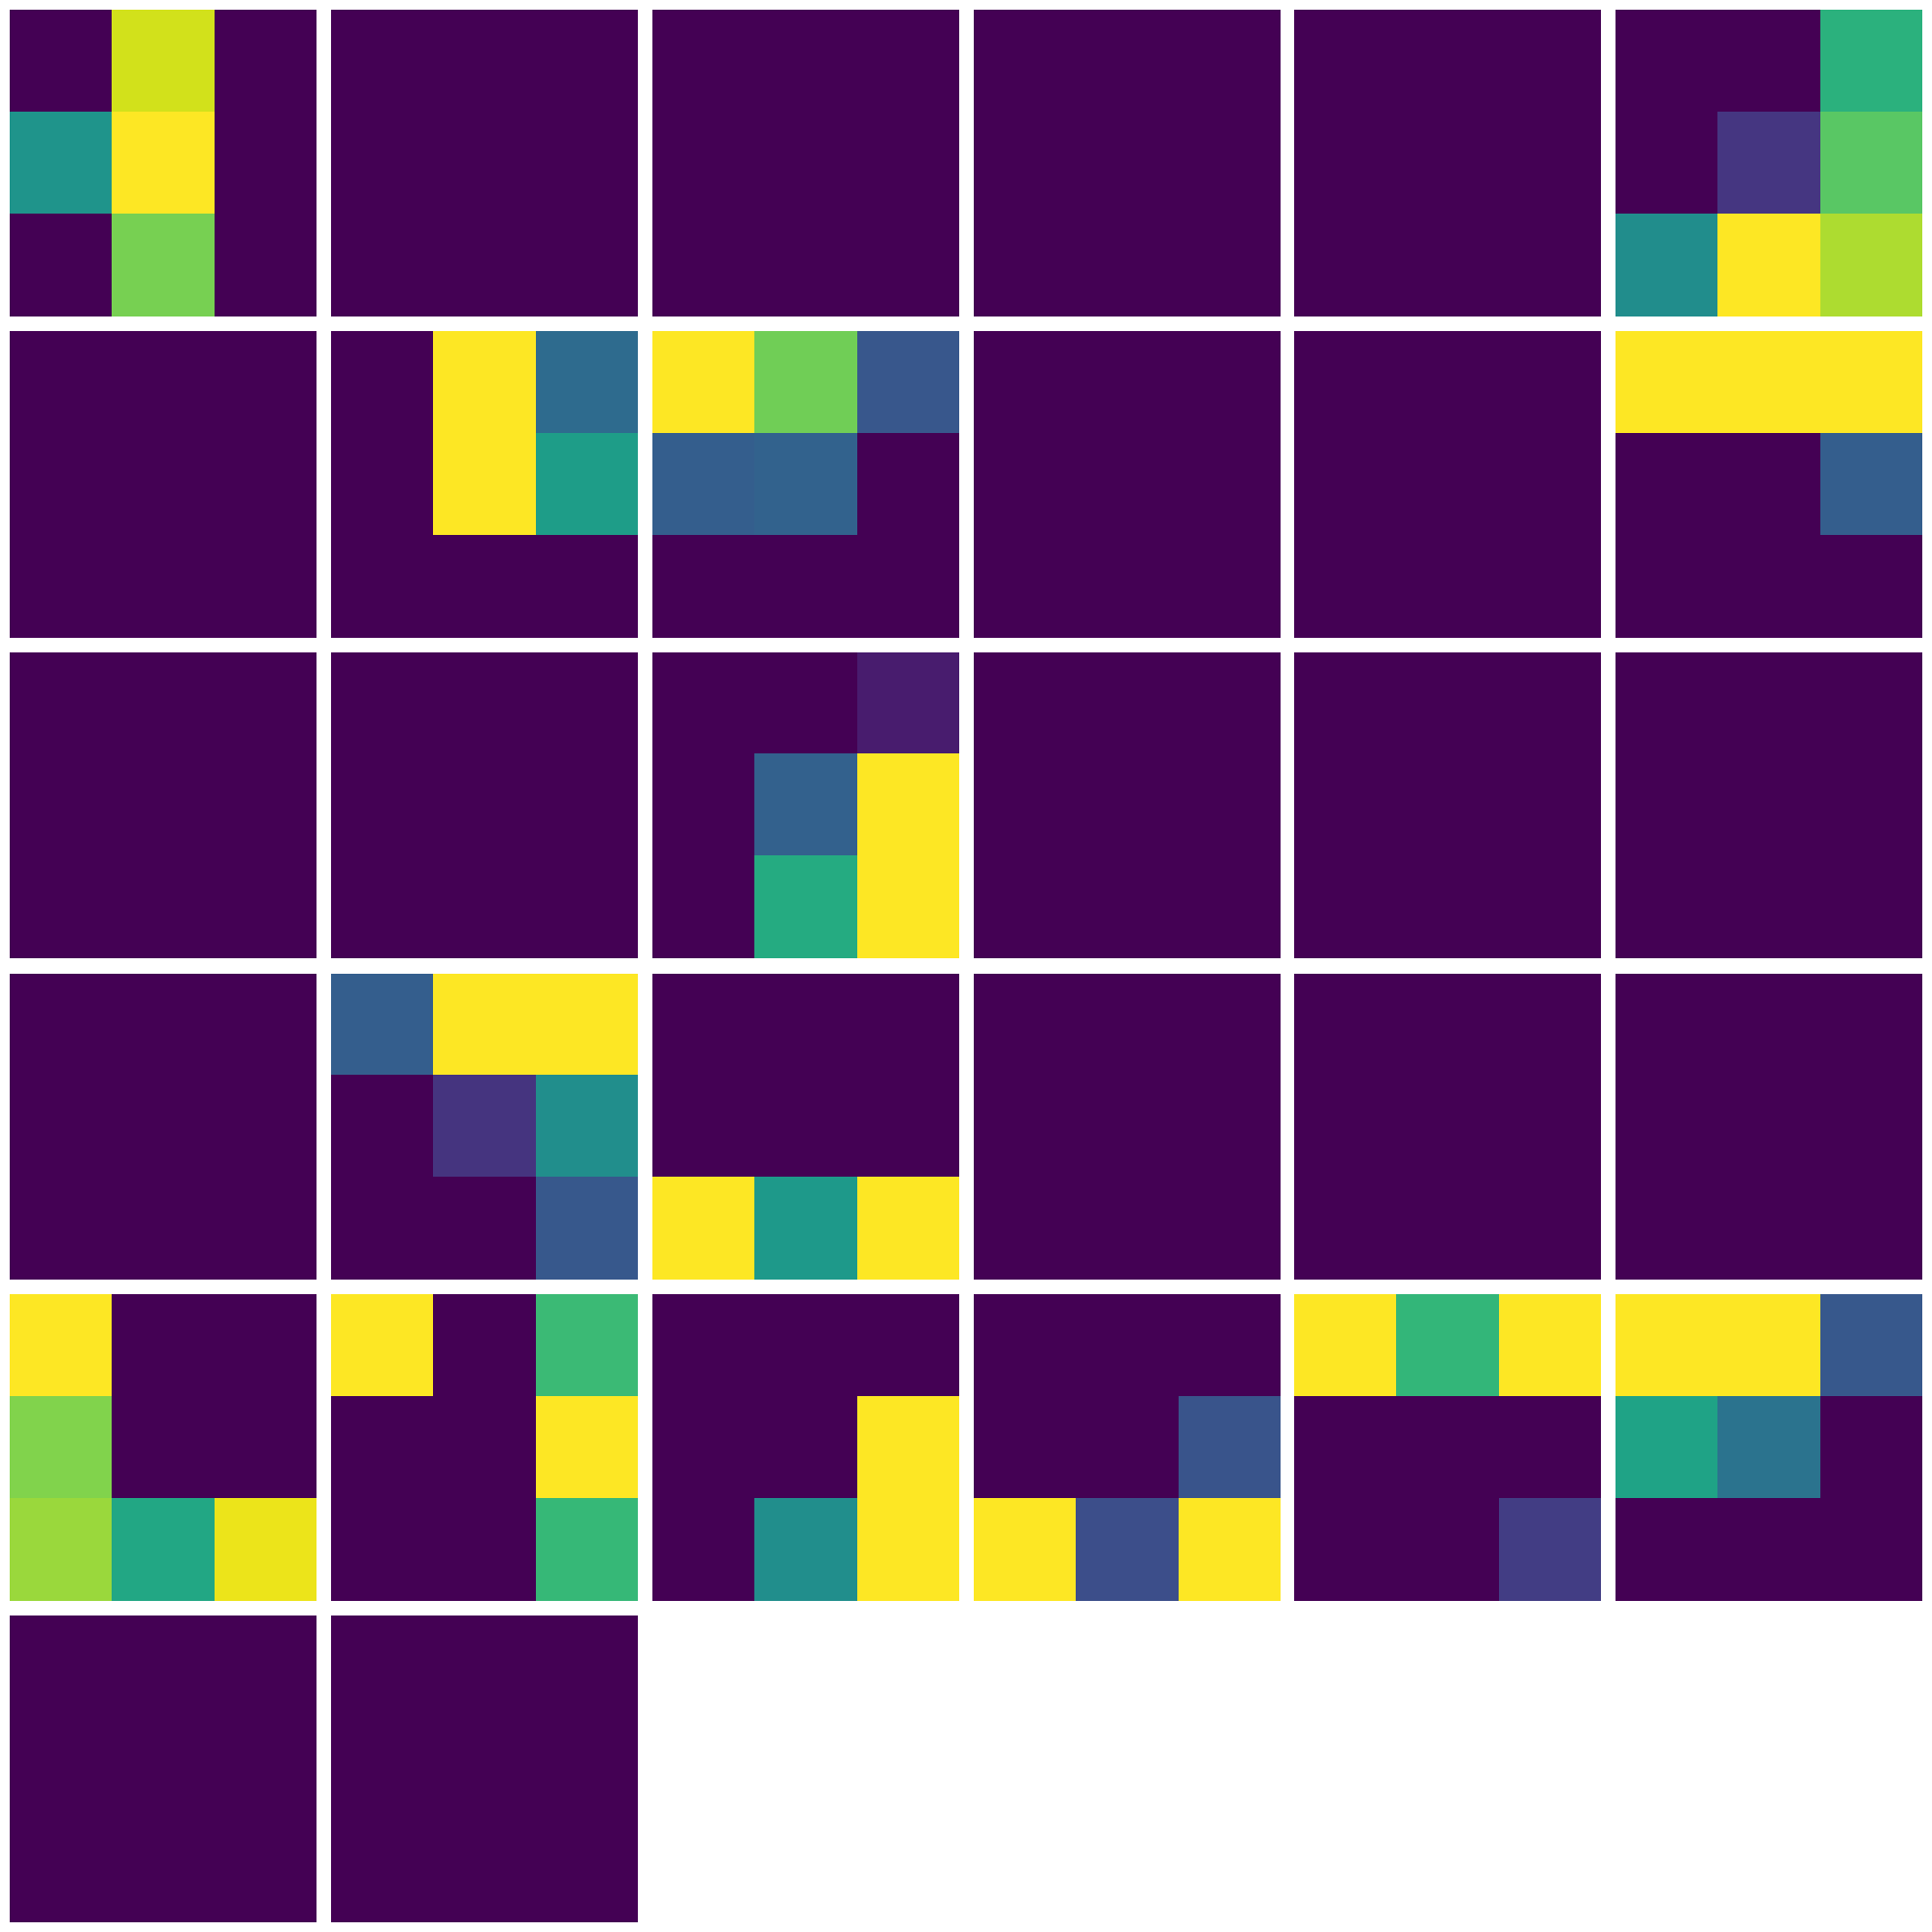

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `model` is your trained model
# Get the weights of the first convolutional layer
first_conv_layer = model.layers[0]  # Modify the index based on your model architecture
filters, biases = first_conv_layer.get_weights()

# Normalize filter values to 0-1 for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

n_filters = filters.shape[-1]
n_channels = filters.shape[-2]

# Determine the grid size
grid_size = int(np.ceil(np.sqrt(n_filters)))

# Plotting the filters as subplots
fig, axes = plt.subplots(grid_size, grid_size, figsize=(20, 20))

for i in range(grid_size * grid_size):
    ax = axes[i // grid_size, i % grid_size]
    if i < n_filters:
        # Get the filter
        f = filters[:, :, :, i]
        # Combine all channels into one image
        combined_image = np.zeros_like(f[:, :, 0])
        for j in range(n_channels):
            combined_image += f[:, :, j]
        # Normalize combined image
        combined_image -= combined_image.mean()
        if combined_image.std() != 0:
            combined_image /= combined_image.std()
        combined_image = np.clip(combined_image, 0, 1)
        ax.imshow(combined_image, cmap='viridis')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [30]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150, 150))  
    return img

def predict_image(image_path):
    preprocessed_image = preprocess_image(image_path)
    preprocessed_image = np.expand_dims(preprocessed_image, axis=0)
    prediction = model.predict(preprocessed_image)
    return prediction

In [31]:
images = os.listdir('/kaggle/input/mytest/testIm')

In [32]:
sortedImages = sorted(images, key = lambda x: int(os.path.splitext(x)[0]))

In [33]:
true_labels = ['RottenBelpepper', 'RottenBelpepper', 'RottenBelpepper', 'FreshBelpepper', 'FreshCucumber', 'FreshCucumber', 'RottenCucumber', 'RottenCucumber', 'FreshApple', 'RottenApple', 'FreshBittergourd', 'FreshBanana', 'RottenBanana', 'FreshOranges', 'RottenOrange', 'FreshGrape', 'RottenGrape','RottenBittergourd']

1/1 [==============================] - 1s 527ms/step


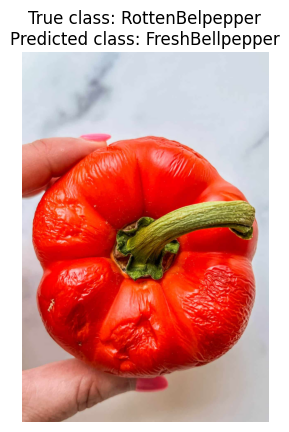

1/1 [==============================] - 0s 18ms/step


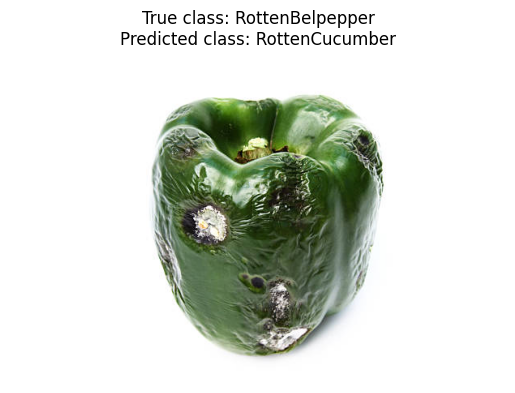

1/1 [==============================] - 0s 20ms/step


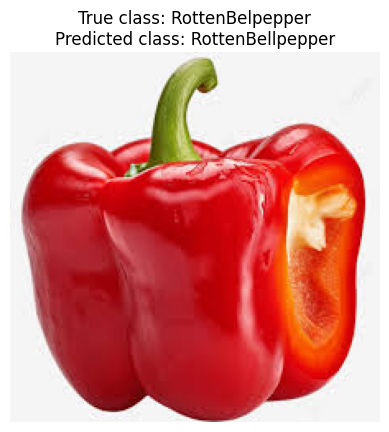

1/1 [==============================] - 0s 20ms/step


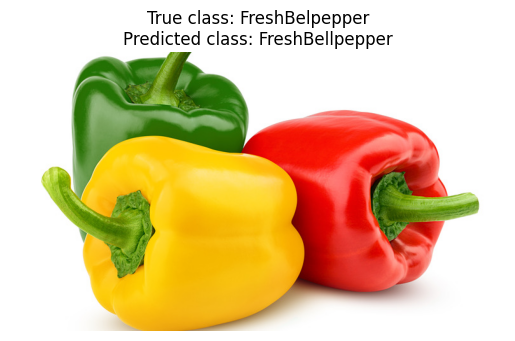

1/1 [==============================] - 0s 21ms/step


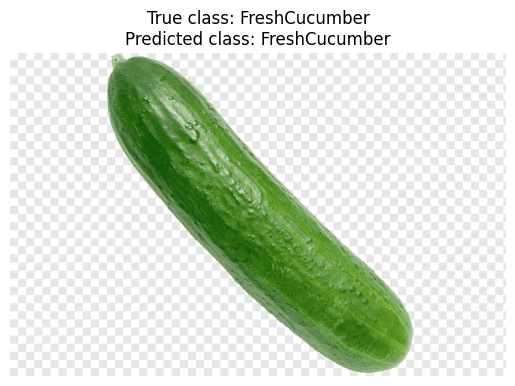

1/1 [==============================] - 0s 19ms/step


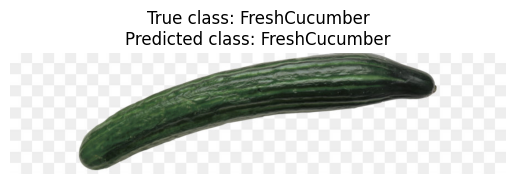

1/1 [==============================] - 0s 20ms/step


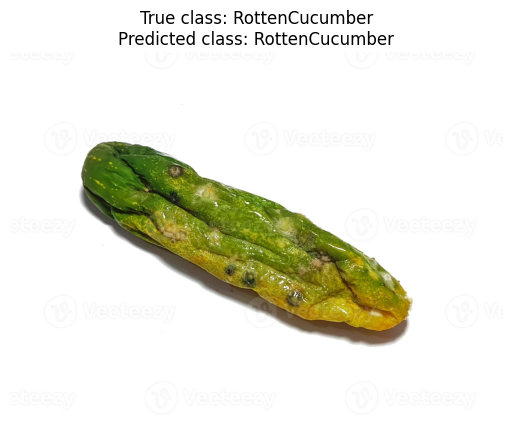

1/1 [==============================] - 0s 21ms/step


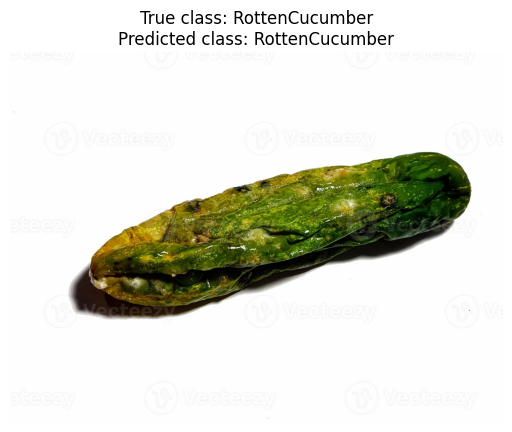

1/1 [==============================] - 0s 22ms/step


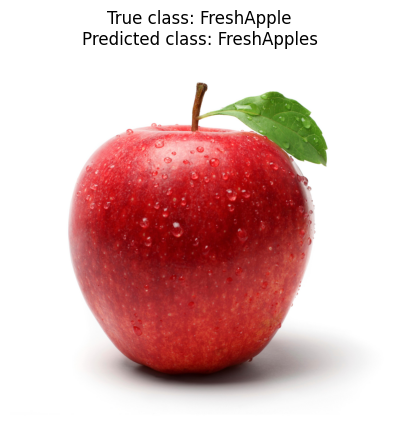

1/1 [==============================] - 0s 19ms/step


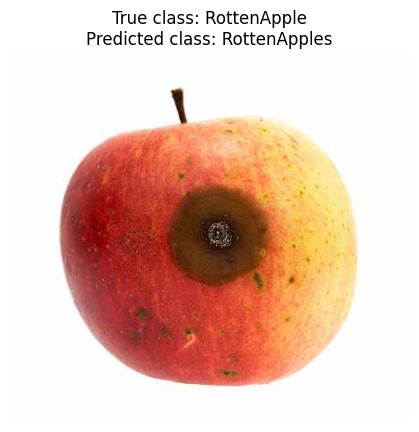

1/1 [==============================] - 0s 20ms/step


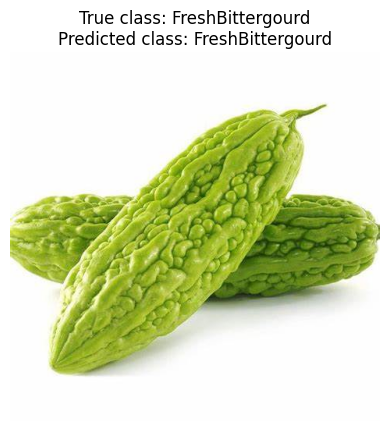

1/1 [==============================] - 0s 19ms/step


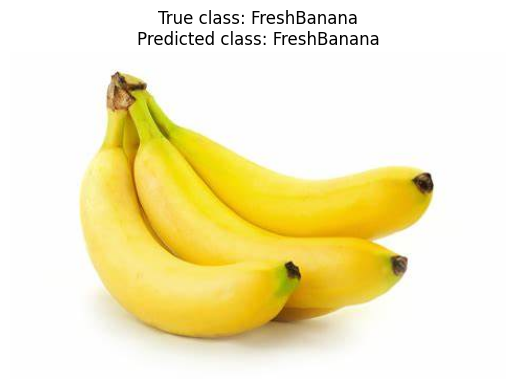

1/1 [==============================] - 0s 18ms/step


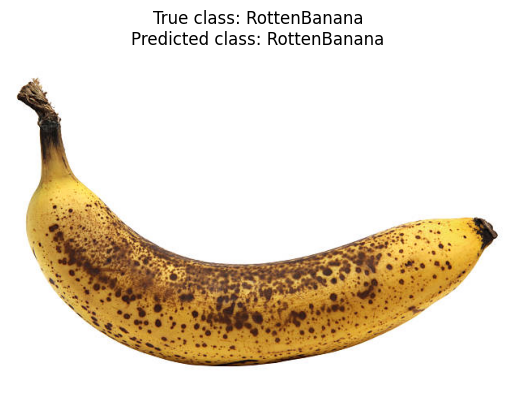

1/1 [==============================] - 0s 20ms/step


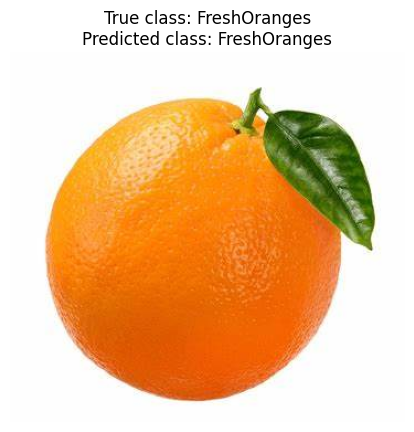

1/1 [==============================] - 0s 20ms/step


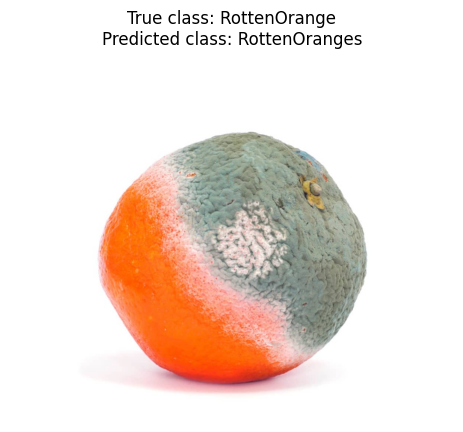

1/1 [==============================] - 0s 20ms/step


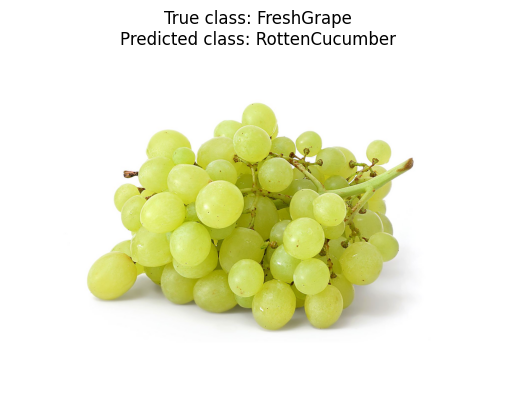

1/1 [==============================] - 0s 19ms/step


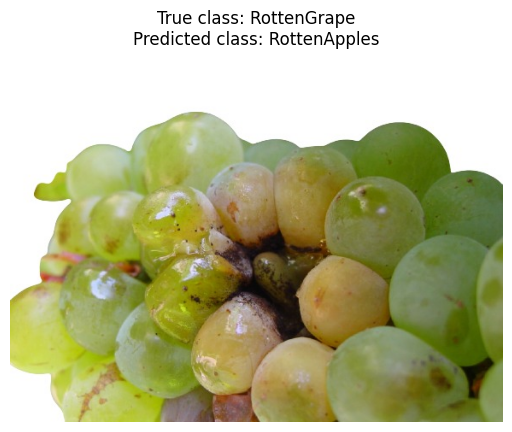

1/1 [==============================] - 0s 19ms/step


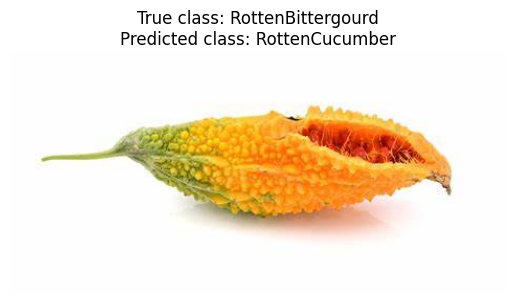

In [34]:
for i, image in enumerate(sortedImages):
    
    path = "/kaggle/input/mytest/testIm/"
    prediction = predict_image(path + image)
    predicted_class_index = np.argmax(prediction)
    predicted_class = target_names[predicted_class_index]
    true_class = true_labels[i]
         
    image = cv2.imread(path + image)
    RGBimage = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(RGBimage)
    plt.title(f'True class: {true_class}\nPredicted class: {predicted_class}')
    plt.axis('off')  
    plt.show()